### Part 4: Data Visualization & Machine Learning

In [1]:
# Create students.csv and load it with pandas

import pandas as pd  

csv_content = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

with open("students.csv", "w", encoding="utf-8") as f:
    f.write(csv_content.strip())

df = pd.read_csv("students.csv")

print("students.csv created and loaded.")
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"Column names: {list(df.columns)}")


students.csv created and loaded.
Dataset has 15 rows and 9 columns.
Column names: ['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']


### Task 1 — Data Exploration with Pandas

In [2]:
# Preview the data with .head()

print("First 5 rows of the dataset:")
print()

print(df.head().to_string(index=True))
print()
print(f"Rows shown: 5 out of {len(df)} total")

# Print shape (rows × columns) and data types of each column

rows, cols = df.shape    

print("=" * 40)
print(" Dataset Dimensions")
print("=" * 40)
print(f"  Rows    (students) : {rows}")
print(f"  Columns (features) : {cols}")
print(f"  Full shape         : {df.shape}   ← (rows, columns)")

print()
print("=" * 40)
print(" Data Type of Each Column")
print("=" * 40)
print()

for col_name, dtype in df.dtypes.items():
    
    if dtype == 'object':
        note = "← text (string)"
    elif dtype == 'float64':
        note = "← decimal number"
    elif dtype == 'int64':
        note = "← whole number (integer)"
    else:
        note = ""
    print(f"  {col_name:<25} {str(dtype):<10}  {note}")

print()
print("  Note: 'passed' is stored as int64 (0 or 1).")
print("        0 = Fail,  1 = Pass")

# summary for all numeric columns 

print("=" * 60)
print(" Summary Statistics for All Numeric Columns")
print("=" * 60)
print()

stats = df.describe().round(2)

print(stats.T.to_string())

print()
print("─" * 60)
print(" Key observations:")
print(f"  Mean math score    : {stats['math']['mean']:.1f}")
print(f"  Highest math score : {stats['math']['max']:.0f}")
print(f"  Lowest math score  : {stats['math']['min']:.0f}")
print(f"  Avg study hrs/day  : {stats['study_hours_per_day']['mean']:.2f} hours")
print(f"  Max study hrs/day  : {stats['study_hours_per_day']['max']:.1f} hours")

# Count of students who passed and failed

counts = df['passed'].value_counts()
proportions = df['passed'].value_counts(normalize=True)

print("=" * 45)
print(" Pass / Fail Student Count")
print("=" * 45)
print()
print("Raw output of .value_counts():")
print(counts)
print()
print("─" * 45)
print(" Formatted breakdown:")
print("─" * 45)

total = len(df)

print(f"  Pass (1) : {counts[1]:>3} students   "
      f"({proportions[1]*100:.1f}% of total)")
print(f"  Fail (0) : {counts[0]:>3} students   "
      f"({proportions[0]*100:.1f}% of total)")
print(f"  Total    : {total:>3} students")
print()
print("  Interpretation: 60% of students passed and 40% failed.")

# Compute average score per subject 

subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_means = df[df['passed'] == 1][subject_cols].mean().round(2)

fail_means = df[df['passed'] == 0][subject_cols].mean().round(2)

print("=" * 52)
print(" Average Score per Subject: Passing vs Failing")
print("=" * 52)
print(f"  {'Subject':<12} {'Passing avg':>12} {'Failing avg':>12} {'Difference':>12}")
print("─" * 52)

for subject in subject_cols:
    p_avg = pass_means[subject]      
    f_avg = fail_means[subject]      
    diff  = p_avg - f_avg            
    print(f"  {subject:<12} {p_avg:>12.2f} {f_avg:>12.2f} {diff:>+12.2f}")

print("─" * 52)
print()
print("  Raw Series output (passing students):")
print(pass_means.to_string())
print()
print("  Raw Series output (failing students):")
print(fail_means.to_string())
print()
print("  Observation: Passing students score 25–40 points higher in every subject.")

# student with the highest average across all 5 subjects

subject_cols = ['math', 'science', 'english', 'history', 'pe']

df['temp_avg'] = df[subject_cols].mean(axis=1).round(2)

top_index = df['temp_avg'].idxmax()

top_student = df.loc[top_index]

print("=" * 55)
print(" Top-Performing Student (Highest Average Across 5 Subjects)")
print("=" * 55)
print()
print(f"  Name            : {top_student['name']}")
print(f"  Math            : {top_student['math']}")
print(f"  Science         : {top_student['science']}")
print(f"  English         : {top_student['english']}")
print(f"  History         : {top_student['history']}")
print(f"  PE              : {top_student['pe']}")
print(f"  Overall Average : {top_student['temp_avg']}")
print(f"  Passed          : {'Yes' if top_student['passed'] == 1 else 'No'}")

# show the sorted ranking

print()
print("─" * 55)
print(" Full ranking (all 15 students, highest average first):")
print("─" * 55)
ranking = df[['name'] + subject_cols + ['temp_avg','passed']]\
              .sort_values('temp_avg', ascending=False)\
              .reset_index(drop=True)  # reset so index shows rank 0,1,2...

for rank, row in ranking.iterrows():
    result = 'Pass' if row['passed'] == 1 else 'Fail'
    print(f"  {rank+1:>2}. {row['name']:<10} avg={row['temp_avg']:>5.2f}  [{result}]")

df.drop(columns=['temp_avg'], inplace=True)

print()
print("  Temporary 'temp_avg' column removed. df is back to its original shape.")
print(f"  df.shape is now: {df.shape}")


First 5 rows of the dataset:

      name  math  science  english  history  pe  attendance_pct  study_hours_per_day  passed
0    Alice    88       92       76       80  95              92                  4.5       1
1      Bob    42       55       48       50  60              65                  1.2       0
2  Charlie    75       70       80       68  88              85                  3.0       1
3    Diana    95       98       91       89  97              98                  6.0       1
4      Eve    38       42       50       45  55              58                  0.8       0

Rows shown: 5 out of 15 total
 Dataset Dimensions
  Rows    (students) : 15
  Columns (features) : 9
  Full shape         : (15, 9)   ← (rows, columns)

 Data Type of Each Column

  name                      object      ← text (string)
  math                      int64       ← whole number (integer)
  science                   int64       ← whole number (integer)
  english                   int64       ← who

### Task 2 — Data Visualization with Matplotlib

In [3]:
# Import libraries, load data, add avg_score column

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  

csv_content = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""
with open("students.csv", "w", encoding="utf-8") as f:
    f.write(csv_content.strip())

df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

print("df['avg_score'] added successfully.")
print(df[['name', 'avg_score']].to_string(index=False))

df['avg_score'] added successfully.
   name  avg_score
  Alice       86.2
    Bob       51.0
Charlie       76.2
  Diana       94.0
    Eve       46.0
  Frank       65.0
  Grace       52.2
  Henry       82.6
   Iris       71.0
   Jack       35.6
  Karen       66.4
   Liam       51.4
    Mia       92.2
   Noah       60.6
 Olivia       78.0


Subject averages:
math       65.00
science    66.73
english    66.20
history    63.40
pe         74.80


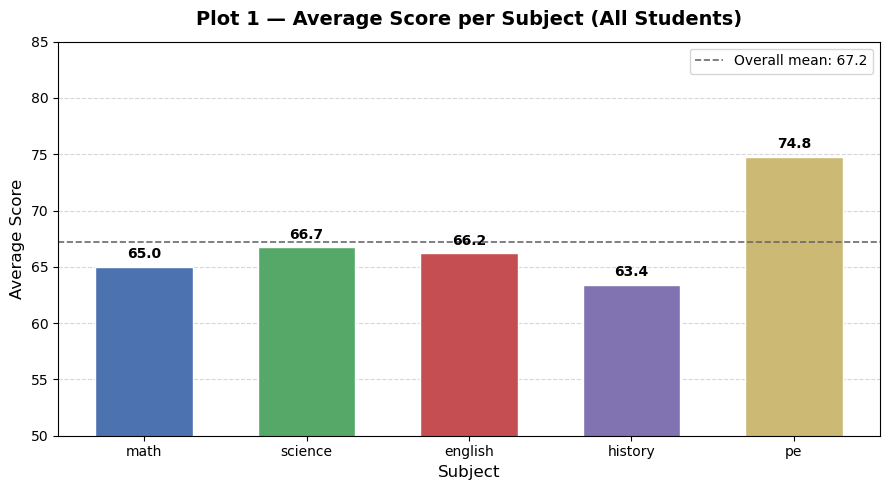

Saved as plot1_bar.png
Highest average subject: pe (74.8)
Lowest  average subject: history (63.4)


In [4]:
# Bar Chart: average score per subject across all students

subject_avgs = df[subject_cols].mean().round(2)
print("Subject averages:")
print(subject_avgs.to_string())

fig, ax = plt.subplots(figsize=(9, 5))

bar_colours = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

bars = ax.bar(
    subject_avgs.index,    
    subject_avgs.values,   
    color     = bar_colours,
    edgecolor = 'white',
    width     = 0.6
)

ax.bar_label(bars, fmt='%.1f', padding=4, fontsize=10, fontweight='bold')

ax.set_title('Plot 1 — Average Score per Subject (All Students)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)

ax.set_ylim(50, 85)

overall_mean = subject_avgs.mean()
ax.axhline(overall_mean, color='dimgrey', linestyle='--', linewidth=1.2,
           label=f'Overall mean: {overall_mean:.1f}')
ax.legend(fontsize=10)

ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)  

plt.tight_layout()
plt.savefig('plot1_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved as plot1_bar.png")
print(f"Highest average subject: {subject_avgs.idxmax()} ({subject_avgs.max():.1f})")
print(f"Lowest  average subject: {subject_avgs.idxmin()} ({subject_avgs.min():.1f})")

Math scores: [30, 38, 42, 48, 55, 58, 60, 65, 70, 75, 78, 82, 88, 91, 95]
Mean math score: 65.00


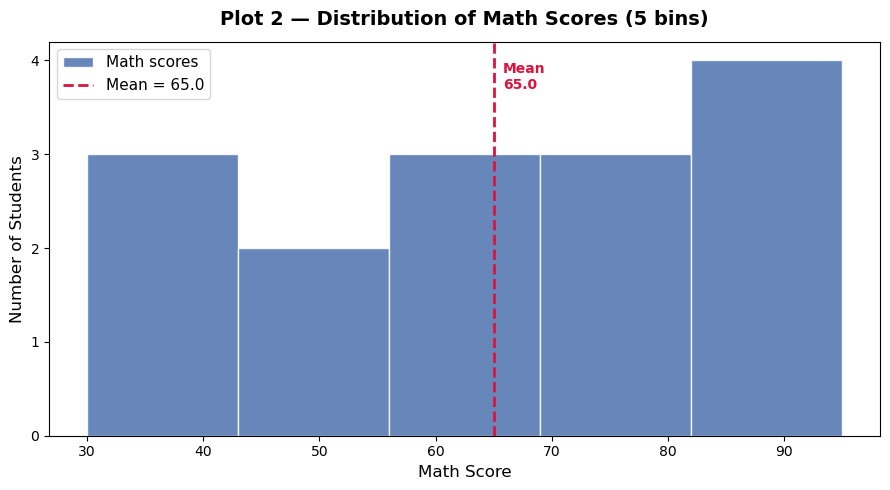

Saved as plot2_histogram.png


In [5]:
# Histogram: distribution of math scores, 5 bins

mean_math = df['math'].mean()   
print(f"Math scores: {sorted(df['math'].tolist())}")
print(f"Mean math score: {mean_math:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df['math'],
    bins      = 5,             
    color     = '#4C72B0',     
    edgecolor = 'white',       
    alpha     = 0.85,
    label     = 'Math scores'  
)

ax.axvline(
    mean_math,
    color     = 'crimson',
    linestyle = '--',          
    linewidth = 2,
    label     = f'Mean = {mean_math:.1f}'
)

ax.text(
    mean_math + 0.8,           
    ax.get_ylim()[1] * 0.88,   
    f'Mean\n{mean_math:.1f}',
    color     = 'crimson',
    fontsize  = 10,
    fontweight= 'bold'
)

ax.set_title('Plot 2 — Distribution of Math Scores (5 bins)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Math Score', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('plot2_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved as plot2_histogram.png")

Pass group: 9 students
Fail group: 6 students


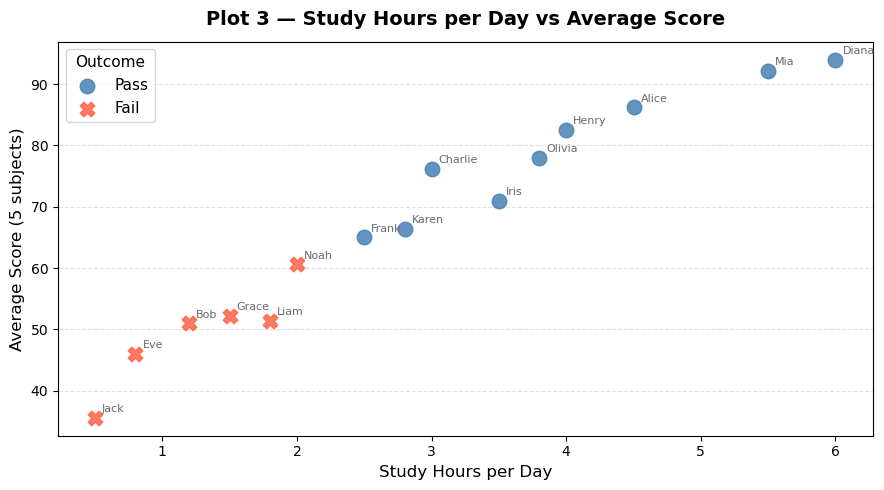

Saved as plot3_scatter.png


In [6]:
# Scatter Plot: study_hours_per_day vs avg_score (Colour-coded by pass/fail status)

pass_df = df[df['passed'] == 1]   
fail_df = df[df['passed'] == 0]   

print(f"Pass group: {len(pass_df)} students")
print(f"Fail group: {len(fail_df)} students")

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    pass_df['study_hours_per_day'],  
    pass_df['avg_score'],            
    color  = 'steelblue',
    marker = 'o',                    
    s      = 110,                    
    alpha  = 0.85,
    label  = 'Pass',
    zorder = 3
)

ax.scatter(
    fail_df['study_hours_per_day'],
    fail_df['avg_score'],
    color  = 'tomato',
    marker = 'X',                    
    s      = 110,
    alpha  = 0.85,
    label  = 'Fail',
    zorder = 3
)

for _, row in df.iterrows():
    ax.annotate(
        row['name'],
        xy         = (row['study_hours_per_day'], row['avg_score']),
        xytext     = (5, 4),             
        textcoords = 'offset points',
        fontsize   = 8,
        color      = 'dimgrey'
    )

ax.set_title('Plot 3 — Study Hours per Day vs Average Score',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Study Hours per Day', fontsize=12)
ax.set_ylabel('Average Score (5 subjects)', fontsize=12)

ax.legend(title='Outcome', fontsize=11, title_fontsize=11, loc='upper left')

ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('plot3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved as plot3_scatter.png")


Pass attendance values: [72, 78, 80, 84, 85, 88, 92, 95, 98]
Fail attendance values: [50, 58, 60, 62, 65, 70]


C:\Users\Gayatri\AppData\Local\Temp\ipykernel_49176\2418957065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


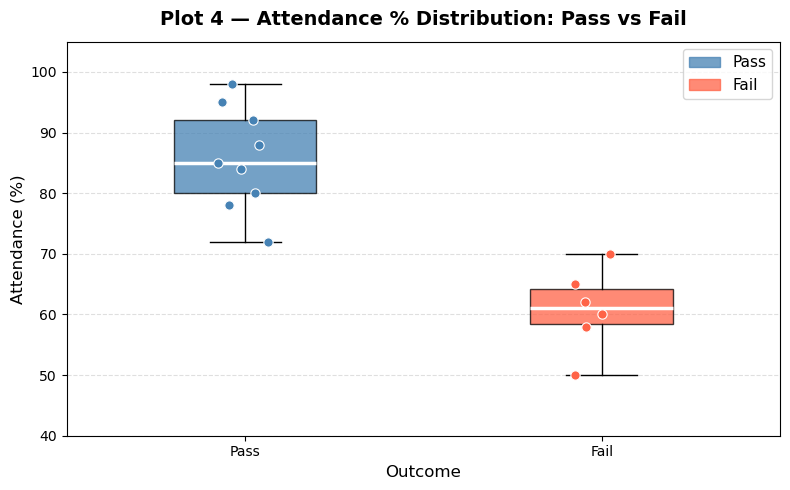

Saved as plot4_boxplot.png
Pass median attendance : 85%
Fail median attendance : 61%


In [7]:
# Box Plot: attendance_pct for passing vs failing 

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

print(f"Pass attendance values: {sorted(pass_attendance)}")
print(f"Fail attendance values: {sorted(fail_attendance)}")

fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(
    [pass_attendance, fail_attendance],
    labels       = ['Pass', 'Fail'],
    patch_artist = True,       
    widths       = 0.4,        
    medianprops  = dict(color='white', linewidth=2.5) 
)

box_colours = ['steelblue', 'tomato']
for patch, colour in zip(bp['boxes'], box_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.75)

import random
random.seed(42)
for i, (values, colour) in enumerate(
        zip([pass_attendance, fail_attendance], box_colours), start=1):
    jitter = [i + random.uniform(-0.08, 0.08) for _ in values]
    ax.scatter(jitter, values, color=colour, s=45, zorder=4,
               edgecolors='white', linewidths=0.8)


ax.set_title('Plot 4 — Attendance % Distribution: Pass vs Fail',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Outcome', fontsize=12)
ax.set_ylabel('Attendance (%)', fontsize=12)
ax.set_ylim(40, 105)

pass_patch = mpatches.Patch(color='steelblue', alpha=0.75, label='Pass')
fail_patch = mpatches.Patch(color='tomato',    alpha=0.75, label='Fail')
ax.legend(handles=[pass_patch, fail_patch], fontsize=11)

ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('plot4_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

import statistics
print("Saved as plot4_boxplot.png")
print(f"Pass median attendance : {statistics.median(pass_attendance):.0f}%")
print(f"Fail median attendance : {statistics.median(fail_attendance):.0f}%")

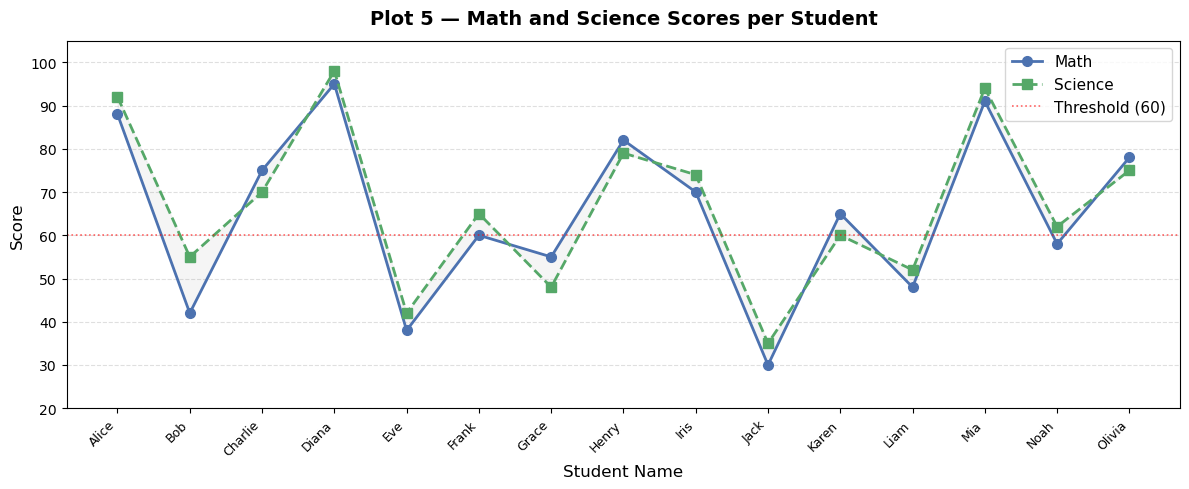

Saved as plot5_line.png


In [8]:
# Line Plot: math and science scores for all student

names         = df['name'].tolist()        
math_scores   = df['math'].tolist()        
science_scores= df['science'].tolist()     

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    names,
    math_scores,
    color      = '#4C72B0',     
    marker     = 'o',           
    linewidth  = 2,
    markersize = 7,
    label      = 'Math'
)

ax.plot(
    names,
    science_scores,
    color      = '#55A868',     
    marker     = 's',           
    linestyle  = '--',          
    linewidth  = 2,
    markersize = 7,
    label      = 'Science'
)

ax.fill_between(names, math_scores, science_scores,
                alpha=0.08, color='grey')

plt.xticks(rotation=45, ha='right', fontsize=9)

ax.set_title('Plot 5 — Math and Science Scores per Student',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Student Name', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(20, 105)

ax.axhline(60, color='red', linestyle=':', linewidth=1.2,
           alpha=0.6, label='Threshold (60)')
ax.legend(fontsize=11)

ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('plot5_line.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved as plot5_line.png")


### Task 3 — Data Visualization with Seaborn

In [9]:
# Imports, load data, add required columns

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

csv_content = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""
with open('students.csv', 'w', encoding='utf-8') as f:
    f.write(csv_content.strip())

df = pd.read_csv('students.csv')

subject_cols    = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1).round(2)

df['Result'] = df['passed'].map({1: 'Pass', 0: 'Fail'})

print('Setup complete.')
print(f"  Rows: {len(df)}  |  Columns: {list(df.columns)}")
print()
print('Result column (string labels):')
print(df[['name', 'passed', 'Result']].to_string(index=False))

Setup complete.
  Rows: 15  |  Columns: ['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed', 'avg_score', 'Result']

Result column (string labels):
   name  passed Result
  Alice       1   Pass
    Bob       0   Fail
Charlie       1   Pass
  Diana       1   Pass
    Eve       0   Fail
  Frank       1   Pass
  Grace       0   Fail
  Henry       1   Pass
   Iris       1   Pass
   Jack       0   Fail
  Karen       1   Pass
   Liam       0   Fail
    Mia       1   Pass
   Noah       0   Fail
 Olivia       1   Pass


In [10]:
# Usage of two Seaborn functions used in this task

print('sns.barplot() — what it does automatically:')
print()

print('  Group means that sns.barplot() will plot:')
for subject in ['math', 'science']:
    means = df.groupby('Result')[subject].mean().round(2)
    print(f'  {subject:<10}: Pass = {means["Pass"]}  |  Fail = {means["Fail"]}')

print()
print('  → We do NOT need to compute these manually.')
print('  → sns.barplot(data=df, x="Result", y="math") does it for us.')
print()
print('sns.regplot() — what it draws:')
print('  • A scatter point for every student in the filtered group')
print('  • A best-fit regression line through those points')
print('  • A shaded 95% confidence band around the line')

sns.barplot() — what it does automatically:

  Group means that sns.barplot() will plot:
  math      : Pass = 78.22  |  Fail = 45.17
  science   : Pass = 78.56  |  Fail = 49.0

  → We do NOT need to compute these manually.
  → sns.barplot(data=df, x="Result", y="math") does it for us.

sns.regplot() — what it draws:
  • A scatter point for every student in the filtered group
  • A best-fit regression line through those points
  • A shaded 95% confidence band around the line


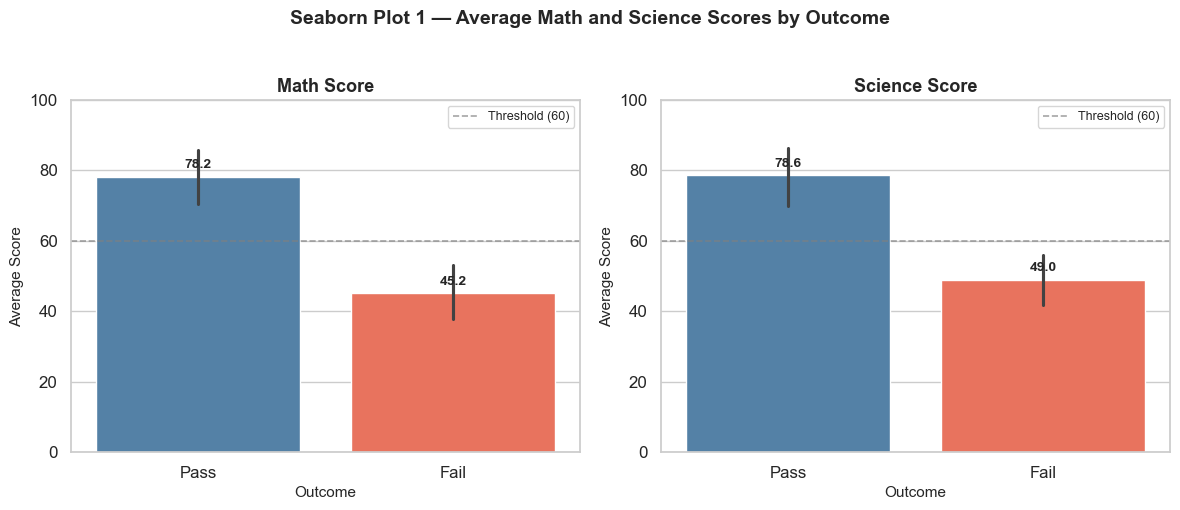

Saved: seaborn_plot1_barplot.png

Group averages (what sns.barplot computed automatically):
         math  science
Result                
Fail    45.17    49.00
Pass    78.22    78.56


In [11]:
# Seaborn Plot 1 — Bar Plots- Math & Science Scores by Outcome

PALETTE = {'Pass': 'steelblue', 'Fail': 'tomato'}
ORDER   = ['Pass', 'Fail']   

plt.figure(figsize=(12, 5))
plt.suptitle('Seaborn Plot 1 — Average Math and Science Scores by Outcome',
             fontsize=14, fontweight='bold', y=1.02)

plt.subplot(1, 2, 1)           
ax1 = plt.gca()                

sns.barplot(
    data    = df,
    x       = 'Result',        
    y       = 'math',          
    palette = PALETTE,         
    order   = ORDER,
    ax      = ax1
)

ax1.set_title('Math Score', fontsize=13, fontweight='bold')
ax1.set_xlabel('Outcome', fontsize=11)
ax1.set_ylabel('Average Score', fontsize=11)
ax1.set_ylim(0, 100)
ax1.axhline(60, color='grey', linestyle='--', linewidth=1.2, alpha=0.7,
            label='Threshold (60)')
ax1.legend(fontsize=9)

for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1.5,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.subplot(1, 2, 2)           
ax2 = plt.gca()

sns.barplot(
    data    = df,
    x       = 'Result',
    y       = 'science',       
    palette = PALETTE,
    order   = ORDER,
    ax      = ax2
)

ax2.set_title('Science Score', fontsize=13, fontweight='bold')
ax2.set_xlabel('Outcome', fontsize=11)
ax2.set_ylabel('Average Score', fontsize=11)
ax2.set_ylim(0, 100)
ax2.axhline(60, color='grey', linestyle='--', linewidth=1.2, alpha=0.7,
            label='Threshold (60)')
ax2.legend(fontsize=9)

for bar in ax2.patches:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1.5,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('seaborn_plot1_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: seaborn_plot1_barplot.png')
print()
print('Group averages (what sns.barplot computed automatically):')
print(df.groupby('Result')[['math','science']].mean().round(2).to_string())


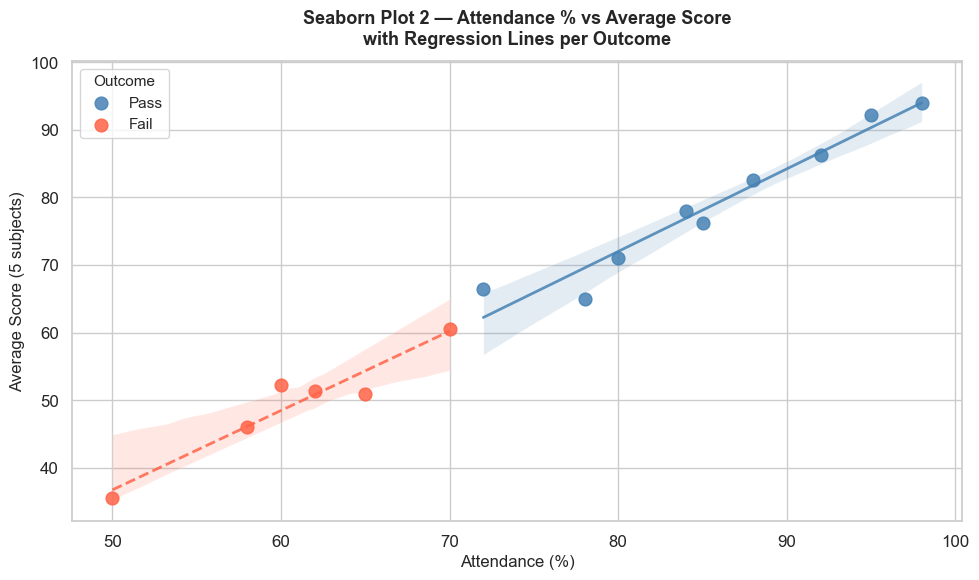

Saved: seaborn_plot2_regplot.png

Data ranges per group:
  Pass: attendance 72–98%  |  avg_score 65.0–94.0
  Fail: attendance 50–70%  |  avg_score 35.6–60.6


In [12]:
# Seaborn Plot 2 — Scatter and Regression -  Attendance vs Avg Score

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data        = df[df['passed'] == 1],   
    x           = 'attendance_pct',
    y           = 'avg_score',
    color       = 'steelblue',
    label       = 'Pass',                  
    scatter_kws = {'s': 85, 'alpha': 0.85, 'zorder': 3},
    line_kws    = {'linewidth': 2, 'alpha': 0.85},
    ax          = ax
)

sns.regplot(
    data        = df[df['passed'] == 0],   
    x           = 'attendance_pct',
    y           = 'avg_score',
    color       = 'tomato',
    label       = 'Fail',
    scatter_kws = {'s': 85, 'alpha': 0.85, 'marker': 'X', 'zorder': 3},
    line_kws    = {'linewidth': 2, 'linestyle': '--', 'alpha': 0.85},
    ax          = ax
)

ax.set_title('Seaborn Plot 2 — Attendance % vs Average Score\n'
             'with Regression Lines per Outcome',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Attendance (%)', fontsize=12)
ax.set_ylabel('Average Score (5 subjects)', fontsize=12)

ax.legend(title='Outcome', fontsize=11, title_fontsize=11)

plt.tight_layout()
plt.savefig('seaborn_plot2_regplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: seaborn_plot2_regplot.png')
print()
print('Data ranges per group:')
for outcome, label in [(1,'Pass'),(0,'Fail')]:
    sub = df[df['passed']==outcome]
    print(f'  {label}: attendance {sub["attendance_pct"].min()}–'
          f'{sub["attendance_pct"].max()}%  |  avg_score {sub["avg_score"].min():.1f}–'
          f'{sub["avg_score"].max():.1f}')


In [13]:
# Comment on Seaborn vs Matplotlib: Comparison

"""
Comparison Summary:

1. Group mean computation - Seaborn is better as it's done automatically
2. Default aesthatics - Seaborn is better as its polished with set theme
3. Color setup - Matplotlib is easier as plain list is accepted
4. Low-level control - Matplotlib is better as it offers pixel-level precision
5. Lines of code - Seaborn we can achieve the same result with lesser code 

In summary
  • Use SEABORN for creating statistical charts quickly with smart defaults.
  • Use MATPLOTLIB for precise, pixel-level control over every element.
  • They work together. That is Seaborn creates the chart, matplotlib fine-tunes it.
  
"""

"\nComparison Summary:\n\n1. Group mean computation - Seaborn is better as it's done automatically\n2. Default aesthatics - Seaborn is better as its polished with set theme\n3. Color setup - Matplotlib is easier as plain list is accepted\n4. Low-level control - Matplotlib is better as it offers pixel-level precision\n5. Lines of code - Seaborn we can achieve the same result with lesser code \n\nIn summary\n  • Use SEABORN for creating statistical charts quickly with smart defaults.\n  • Use MATPLOTLIB for precise, pixel-level control over every element.\n  • They work together. That is Seaborn creates the chart, matplotlib fine-tunes it.\n\n"

### Task 4 — Machine Learning with scikit-learn

In [14]:
# Install, import, load data

import subprocess, sys
for pkg in ['pandas','numpy','matplotlib','scikit-learn']:
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q','--break-system-packages'])

import pandas  as pd
import numpy   as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split   
from sklearn.preprocessing   import StandardScaler     
from sklearn.linear_model    import LogisticRegression 
from sklearn.metrics         import (accuracy_score,   
                                      classification_report,
                                      confusion_matrix)

csv_content = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""
with open('students.csv', 'w', encoding='utf-8') as f:
    f.write(csv_content.strip())

df = pd.read_csv('students.csv')

print('Dataset loaded.')
print(f'  Shape: {df.shape}  —  {df.shape[0]} students × {df.shape[1]} columns')
print(f'  Columns: {list(df.columns)}')
print()
print('Pass / Fail distribution:')
print(f'  Pass (1): {(df["passed"]==1).sum()} students')
print(f'  Fail (0): {(df["passed"]==0).sum()} students')


Dataset loaded.
  Shape: (15, 9)  —  15 students × 9 columns
  Columns: ['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']

Pass / Fail distribution:
  Pass (1): 9 students
  Fail (0): 6 students


In [15]:
# Step 1 Prepare data (features/target split, train/test split, scaling)

feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]   
y = df['passed']       

print('Feature matrix X:')
print(f'  Shape: {X.shape}  (rows=students, cols=features)')
print(f'  Columns: {list(X.columns)}')
print(f'  "name" still in df: {"name" in df.columns}  ← df is untouched')
print(f'  "name" in X:        {"name" in X.columns}   ← correctly excluded')
print()
print(f'Target y:  {y.tolist()}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,    
    random_state = 42      
)

print()
print('Train / Test split:')
print(f'  X_train: {X_train.shape}  (12 students, 7 features)')
print(f'  X_test:  {X_test.shape}   (3 students,  7 features)')
print(f'  y_train: {y_train.tolist()}')
print(f'  y_test:  {y_test.tolist()}')
print(f'  Test set row indices: {X_test.index.tolist()}')
test_names = df.loc[X_test.index, 'name'].tolist()
print(f'  Test set student names: {test_names}')

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled  = scaler.transform(X_test)        

print()
print('Scaling complete (StandardScaler):')
print(f'  X_train_scaled shape: {X_train_scaled.shape}')
print(f'  Mean of each col (should be ~0): {X_train_scaled.mean(axis=0).round(2)}')
print(f'  Std  of each col (should be ~1): {X_train_scaled.std(axis=0).round(2)}')


Feature matrix X:
  Shape: (15, 7)  (rows=students, cols=features)
  Columns: ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
  "name" still in df: True  ← df is untouched
  "name" in X:        False   ← correctly excluded

Target y:  [1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1]

Train / Test split:
  X_train: (12, 7)  (12 students, 7 features)
  X_test:  (3, 7)   (3 students,  7 features)
  y_train: [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0]
  y_test:  [0, 0, 1]
  Test set row indices: [9, 11, 0]
  Test set student names: ['Jack', 'Liam', 'Alice']

Scaling complete (StandardScaler):
  X_train_scaled shape: (12, 7)
  Mean of each col (should be ~0): [-0.  0. -0. -0.  0.  0. -0.]
  Std  of each col (should be ~1): [1. 1. 1. 1. 1. 1. 1.]


In [16]:
# Step 2 Train the model (Train LogisticRegression, print training accuracy)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)   

print('Model trained successfully!')
print(f'  Model type: {type(model).__name__}')
print(f'  Trained on: {X_train_scaled.shape[0]} students')
print(f'  Features:   {X_train_scaled.shape[1]} columns')

train_acc = model.score(X_train_scaled, y_train)
print()
print('=' * 45)
print(f' Training Accuracy: {train_acc*100:.1f}%')
print('=' * 45)
print()
print('  model.score() = fraction of training students correctly classified')
print(f'  = {int(train_acc * len(y_train))} out of {len(y_train)} training students predicted correctly')
print()
print('  Note: 100% training accuracy is expected on a small, well-separated')
print('  dataset like this. It tells us the model fit the training data well.')
print('  The true test is the unseen TEST set (evaluated in Step 3).')

Model trained successfully!
  Model type: LogisticRegression
  Trained on: 12 students
  Features:   7 columns

 Training Accuracy: 100.0%

  model.score() = fraction of training students correctly classified
  = 12 out of 12 training students predicted correctly

  Note: 100% training accuracy is expected on a small, well-separated
  dataset like this. It tells us the model fit the training data well.
  The true test is the unseen TEST set (evaluated in Step 3).


In [17]:
# Step 3 - Evluate the Model (predict on test set, per-student results)

y_pred   = model.predict(X_test_scaled)   
test_acc = accuracy_score(y_test, y_pred)

print('=' * 45)
print(f' Test Accuracy: {test_acc*100:.1f}%')
print('=' * 45)
print(f'  {int(test_acc * len(y_test))} out of {len(y_test)} test students predicted correctly')

print()
print('─' * 55)
print(f" {'Name':<12} {'Actual':>8} {'Predicted':>11} {'Correct?':>10}")
print('─' * 55)

student_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(student_names, y_test, y_pred):
    label_actual    = 'Pass' if actual == 1 else 'Fail'
    label_predicted = 'Pass' if pred   == 1 else 'Fail'
    correct_mark    = '✅ Correct' if actual == pred else '❌ Wrong'
    print(f"  {name:<12} {label_actual:>8} {label_predicted:>11} {correct_mark:>10}")

print('─' * 55)

print()
print('Full Classification Report:')
print('(Based on 3 test students — treat as illustrative only)')
print()
print(classification_report(
    y_test, y_pred,
    target_names = ['Fail (0)', 'Pass (1)'],
    zero_division = 0
))


 Test Accuracy: 100.0%
  3 out of 3 test students predicted correctly

───────────────────────────────────────────────────────
 Name           Actual   Predicted   Correct?
───────────────────────────────────────────────────────
  Jack             Fail        Fail  ✅ Correct
  Liam             Fail        Fail  ✅ Correct
  Alice            Pass        Pass  ✅ Correct
───────────────────────────────────────────────────────

Full Classification Report:
(Based on 3 test students — treat as illustrative only)

              precision    recall  f1-score   support

    Fail (0)       1.00      1.00      1.00         2
    Pass (1)       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



 Feature Coefficients (sorted by absolute importance)
 Feature                    Coefficient  Direction
─────────────────────────────────────────────────────────────────
  english                   +0.8125       pushes → PASS ↑
  attendance_pct            +0.5219       pushes → PASS ↑
  study_hours_per_day       +0.4844       pushes → PASS ↑
  pe                        +0.4750       pushes → PASS ↑
  math                      +0.4379       pushes → PASS ↑
  science                   +0.3230       pushes → PASS ↑
  history                   +0.2629       pushes → PASS ↑
─────────────────────────────────────────────────────────────────

  Most important feature: english
  Least important feature: history


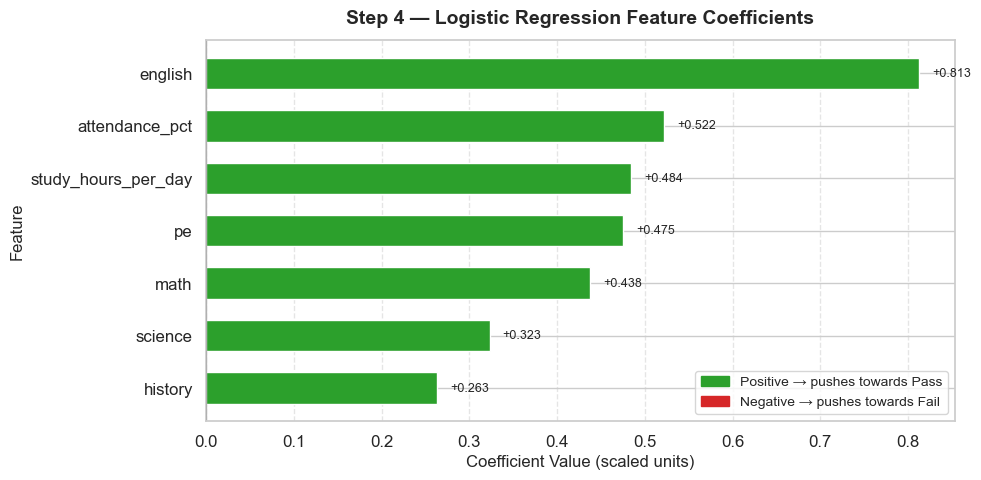

Saved: task4_coefficients.png


In [18]:
# Step 4 - Feature Importance (extract coefficients, print them, bar chart)

raw_coefficients = model.coef_[0]   

coef_series = pd.Series(raw_coefficients, index=feature_cols)\
                .sort_values(key=abs, ascending=False)

print('=' * 65)
print(' Feature Coefficients (sorted by absolute importance)')
print('=' * 65)
print(f" {'Feature':<25} {'Coefficient':>12}  Direction")
print('─' * 65)

for feature, coef in coef_series.items():
    direction = 'pushes → PASS ↑' if coef > 0 else 'pushes → FAIL ↓'
    bar       = '█' * int(abs(coef) * 10)   
    print(f"  {feature:<25} {coef:>+.4f}       {direction}")

print('─' * 65)
print()
print(f'  Most important feature: {coef_series.index[0]}')
print(f'  Least important feature: {coef_series.index[-1]}')

%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 5))

coef_chart = coef_series.sort_values(ascending=True)

bar_colours = ['#2ca02c' if v > 0 else '#d62728' for v in coef_chart.values]

bars = ax.barh(
    coef_chart.index,   
    coef_chart.values,  
    color     = bar_colours,
    edgecolor = 'white',
    height    = 0.6
)

for bar, val in zip(bars, coef_chart.values):
    offset = 0.015 if val >= 0 else -0.015
    ax.text(
        val + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='-')

from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#2ca02c', label='Positive → pushes towards Pass'),
    Patch(color='#d62728', label='Negative → pushes towards Fail'),
]
ax.legend(handles=legend_handles, fontsize=10, loc='lower right')

ax.set_title('Step 4 — Logistic Regression Feature Coefficients',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Coefficient Value (scaled units)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('task4_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task4_coefficients.png')

In [19]:
# Step 5 - Predit for a new student (Bonus)

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

print('=' * 55)
print(' New Student Profile')
print('=' * 55)
for feat, val in zip(feature_cols, new_student[0]):
    print(f'  {feat:<25}: {val}')

new_scaled = scaler.transform(new_student)

print()
print('Scaled values (for reference):')
for feat, val in zip(feature_cols, new_scaled[0]):
    print(f'  {feat:<25}: {val:+.3f}  standard deviations from training mean')

prediction   = model.predict(new_scaled)[0]        
probabilities = model.predict_proba(new_scaled)[0]  

outcome    = 'PASS ✅' if prediction == 1 else 'FAIL ❌'
confidence = probabilities[1] if prediction == 1 else probabilities[0]

print()
print('=' * 55)
print(f' Prediction: {outcome}')
print('─' * 55)
print(f' Probability of PASS : {probabilities[1]*100:.2f}%')
print(f' Probability of FAIL : {probabilities[0]*100:.2f}%')
print(f' Model confidence    : {confidence*100:.2f}%')
print('─' * 55)
print(f' probabilities[0] = {probabilities[0]:.4f}  (P(Fail))')
print(f' probabilities[1] = {probabilities[1]:.4f}  (P(Pass))')
print(f' Total             = {sum(probabilities):.4f}  (must always = 1.0)')
print('=' * 55)
print()
print('Decision rule: predict PASS if probabilities[1] >= 0.5')
print(f'  probabilities[1] = {probabilities[1]:.4f}  '
      f"-> {'≥' if probabilities[1]>=0.5 else '<'} 0.5 "
      f"-> {'PASS' if prediction==1 else 'FAIL'}")


 New Student Profile
  math                     : 75
  science                  : 70
  english                  : 68
  history                  : 65
  pe                       : 80
  attendance_pct           : 82
  study_hours_per_day      : 3.2

Scaled values (for reference):
  math                     : +0.443  standard deviations from training mean
  science                  : +0.093  standard deviations from training mean
  english                  : -0.089  standard deviations from training mean
  history                  : -0.048  standard deviations from training mean
  pe                       : +0.219  standard deviations from training mean
  attendance_pct           : +0.340  standard deviations from training mean
  study_hours_per_day      : +0.097  standard deviations from training mean

 Prediction: PASS ✅
───────────────────────────────────────────────────────
 Probability of PASS : 90.80%
 Probability of FAIL : 9.20%
 Model confidence    : 90.80%
────────────────────────